In [18]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

import category_encoders as ce      # 'category_encoders' is used for Binary Encoding

import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('house price prediction.csv')
print(df.columns)
df.head()

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [20]:
# changing column order
df = df[['date', 'statezip', 'city', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',  'price']]

# printing unique values
print(df.nunique())

print('\nSHAPE OF THE DATA : ', df.shape)
df.head()


date               70
statezip           77
city               44
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
price            1741
dtype: int64

SHAPE OF THE DATA :  (4600, 16)


,date,statezip,city,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,WA 98133,Shoreline,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,WA 98119,Seattle,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,WA 98042,Kent,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,WA 98008,Bellevue,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,WA 98052,Redmond,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


### **Approach for Feature Selection**


- OneHotEncoder - country
- For city we will be using Binary Encoder, applying One hot encoder on it will be messy
- Remove the 'WA' in statezip
- Covert date into date format



In [21]:
# applying Binary Encoder on 'city'
encoder = ce.BinaryEncoder(cols='city')        # make sure, here you must mention the feature name for which you want to use Binary Encoder

df = encoder.fit_transform(df)                 # keep in mind, BinaryEncoder only expects a pandas DataFrame, you cant put any list or array. Else will throw error
df.head()

,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,WA 98133,0,0,0,0,0,1,3.0,1.50,...,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,WA 98119,0,0,0,0,1,0,5.0,2.50,...,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,WA 98042,0,0,0,0,1,1,3.0,2.00,...,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,WA 98008,0,0,0,1,0,0,3.0,2.25,...,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,WA 98052,0,0,0,1,0,1,4.0,2.50,...,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [22]:
# removing 'WA' from all the values in 'statezip'

# df['statezip'] = df['statezip'].str.split().str[-1].astype(int)
df['statezip'] = df['statezip'].str.replace('WA', '')
# df['statezip'] = df['statezip'].astype('int')           # convering numbers into integers
df['statezip'] = df['statezip']        # dont convert zip into integers, coz for eg the model will consider  Zip 98133 is "greater" than Zip 98001

# print(df.info())
df.head()


,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,98133,0,0,0,0,0,1,3.0,1.50,...,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,98119,0,0,0,0,1,0,5.0,2.50,...,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,98042,0,0,0,0,1,1,3.0,2.00,...,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,98008,0,0,0,1,0,0,3.0,2.25,...,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,98052,0,0,0,1,0,1,4.0,2.50,...,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [23]:
# applying datetime format on 'date'

df['date'] = pd.to_datetime(df['date'])     
# keep in mind, after converting it into datetime format, if you run this feature in linear reg, it will throw error
# hence you have to drop this feature. But if you drop this feature you would loose all the seasonal trends that how it affects the price
# to avoid this, you have to extract new features for day, month, and year


# day
df['day'] = df['date'].dt.dayofweek

# month
df['month'] = df['date'].dt.month

# year
df['year'] = df['date'].dt.year   



df.head()

,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price,day,month,year
0,2014-05-02,98133,0,0,0,0,0,1,3.0,1.50,...,0,3,1340,0,1955,2005,313000.0,4,5,2014
1,2014-05-02,98119,0,0,0,0,1,0,5.0,2.50,...,4,5,3370,280,1921,0,2384000.0,4,5,2014
2,2014-05-02,98042,0,0,0,0,1,1,3.0,2.00,...,0,4,1930,0,1966,0,342000.0,4,5,2014
3,2014-05-02,98008,0,0,0,1,0,0,3.0,2.25,...,0,4,1000,1000,1963,0,420000.0,4,5,2014
4,2014-05-02,98052,0,0,0,1,0,1,4.0,2.50,...,0,4,1140,800,1976,1992,550000.0,4,5,2014


In [24]:
df2 = df[['month', 'city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5', 'sqft_living', 'sqft_lot', 'waterfront', 'view', 'price']]
# since year and country are both constant feature adding no value, hence we have to remove them 


df2.head()

,month,city_0,city_1,city_2,city_3,city_4,city_5,sqft_living,sqft_lot,waterfront,view,price
0,5,0,0,0,0,0,1,1340,7912,0,0,313000.0
1,5,0,0,0,0,1,0,3650,9050,0,4,2384000.0
2,5,0,0,0,0,1,1,1930,11947,0,0,342000.0
3,5,0,0,0,1,0,0,2000,8030,0,0,420000.0
4,5,0,0,0,1,0,1,1940,10500,0,0,550000.0


In [25]:
df2.corr()

,month,city_0,city_1,city_2,city_3,city_4,city_5,sqft_living,sqft_lot,waterfront,view,price
month,1.000000,0.002432,-0.014704,0.010923,0.018102,-0.003222,0.011469,0.032825,-0.023286,0.007530,-0.011304,0.041081
city_0,0.002432,1.000000,-0.090675,-0.080389,0.054441,-0.007072,0.099007,-0.034550,0.145213,0.085915,0.048597,-0.024055
city_1,-0.014704,-0.090675,1.000000,0.009021,0.005425,-0.094826,0.183831,0.113237,0.104460,0.022896,-0.000752,-0.025226
city_2,0.010923,-0.080389,0.009021,1.000000,0.228213,-0.146603,0.142666,0.137000,0.036313,0.022502,-0.021344,-0.012256
city_3,0.018102,0.054441,0.005425,0.228213,1.000000,-0.406211,0.206014,0.210280,0.105982,0.018301,0.001535,0.083988
city_4,-0.003222,-0.007072,-0.094826,-0.146603,-0.406211,1.000000,-0.250347,-0.232760,-0.062877,-0.019904,0.000112,-0.085123
city_5,0.011469,0.099007,0.183831,0.142666,0.206014,-0.250347,1.000000,0.073514,0.098190,0.044039,-0.039891,-0.093214
sqft_living,0.032825,-0.034550,0.113237,0.137000,0.210280,-0.232760,0.073514,1.000000,0.210538,0.117616,0.311009,0.430410
sqft_lot,-0.023286,0.145213,0.104460,0.036313,0.105982,-0.062877,0.098190,0.210538,1.000000,0.017241,0.073907,0.050451
waterfront,0.007530,0.085915,0.022896,0.022502,0.018301,-0.019904,0.044039,0.117616,0.017241,1.000000,0.360935,0.135648


In [26]:
X = df2.drop(columns=['price'])
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = pd.DataFrame(lr.predict(X_test))

# y_pred


print(f"R2 SCORE : {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")




R2 SCORE : 0.06648944350096331
MAE : 189337.04752717406
MSE : 674416553349.952


In [27]:
X = df2.drop(columns=['price'])
y = df2['price']

std = StandardScaler()
X = std.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = pd.DataFrame(lr.predict(X_test))

# y_pred


print(f"R2 SCORE : {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")




R2 SCORE : 0.03692501223796152
MAE : 203431.91249065826
MSE : 982188501498.4036


In [28]:
df2['price'] = df2['price'].astype('int')       # converting prince into integer

### **Removing Outliers**

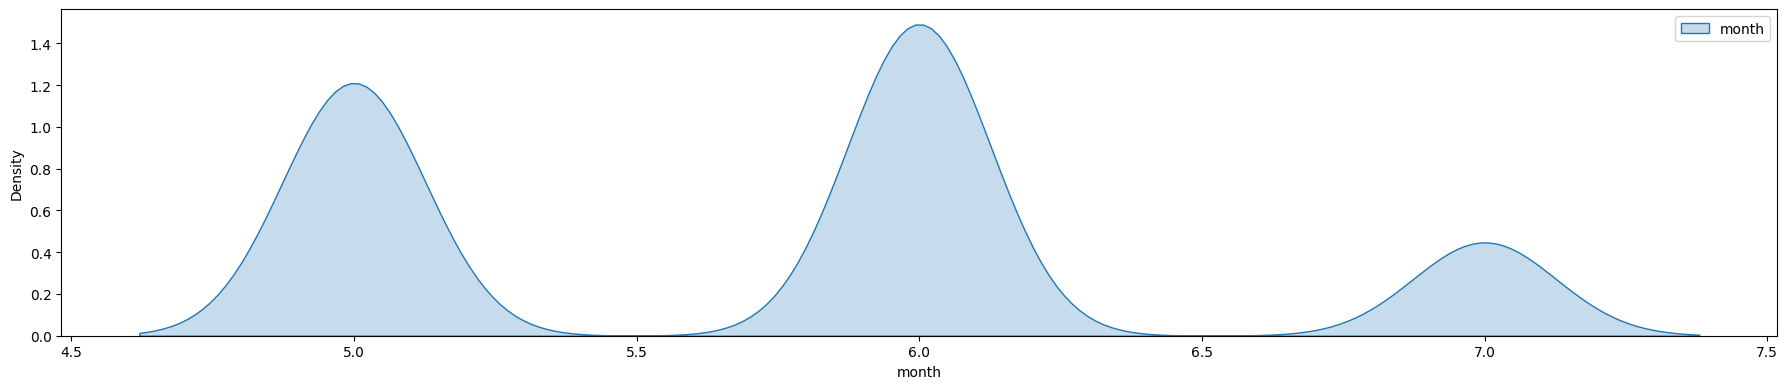

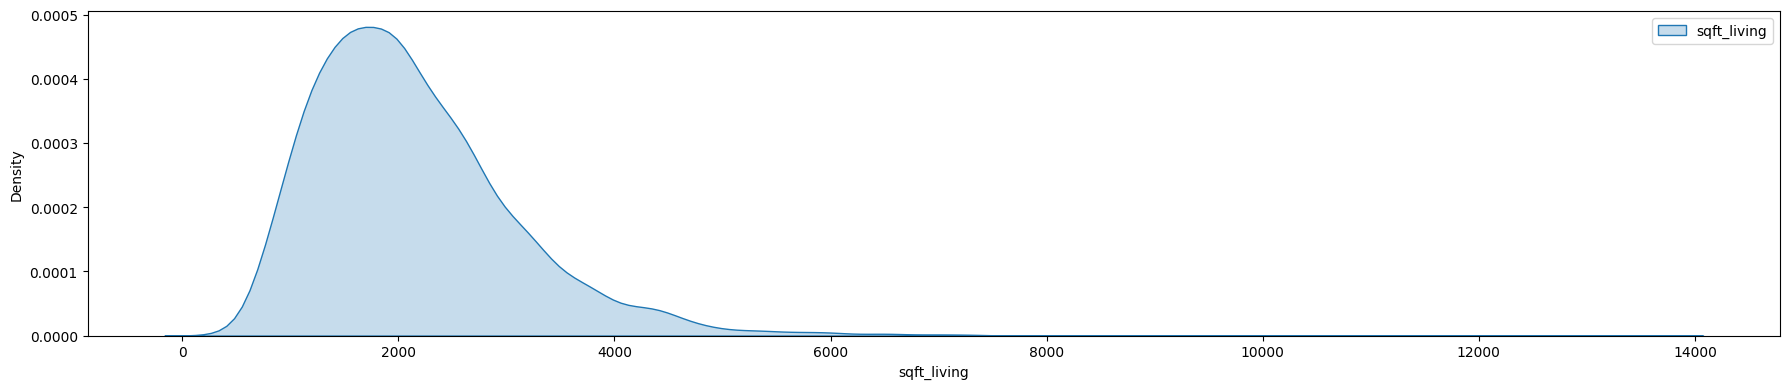

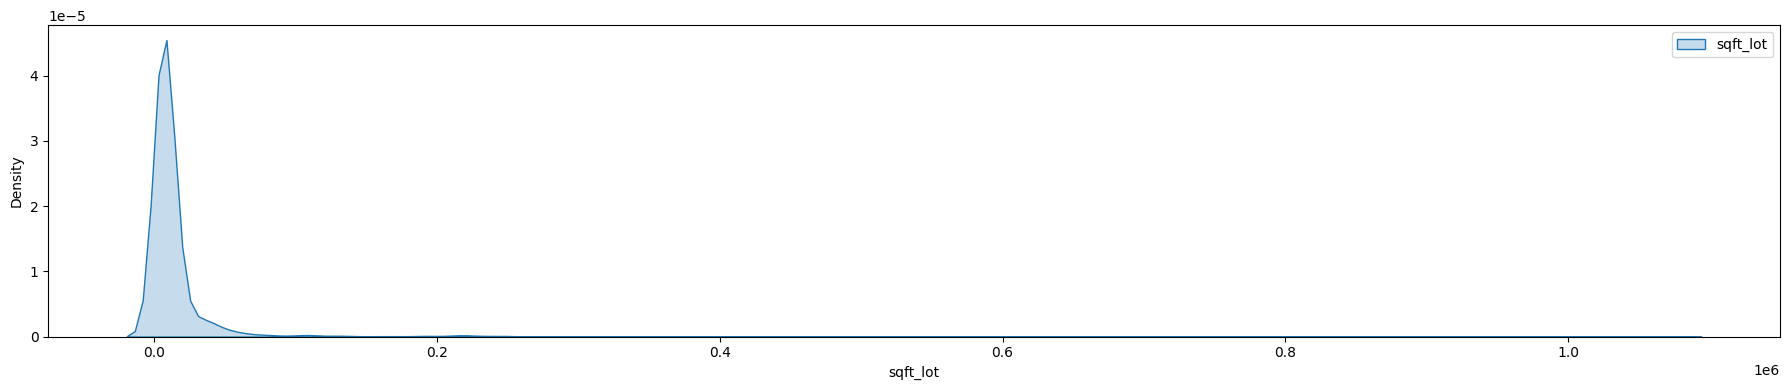

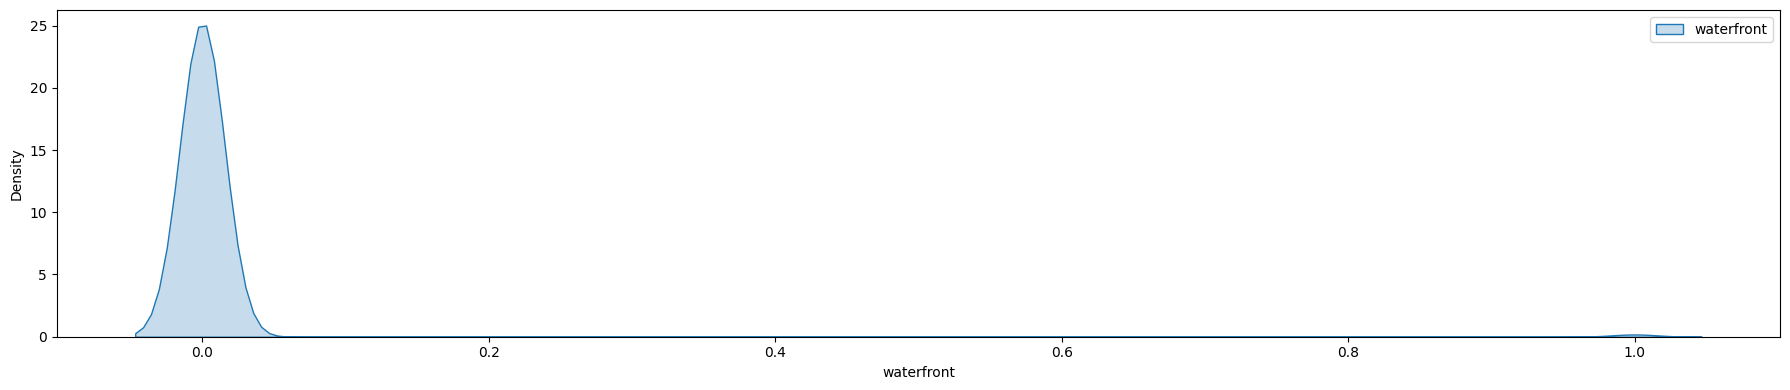

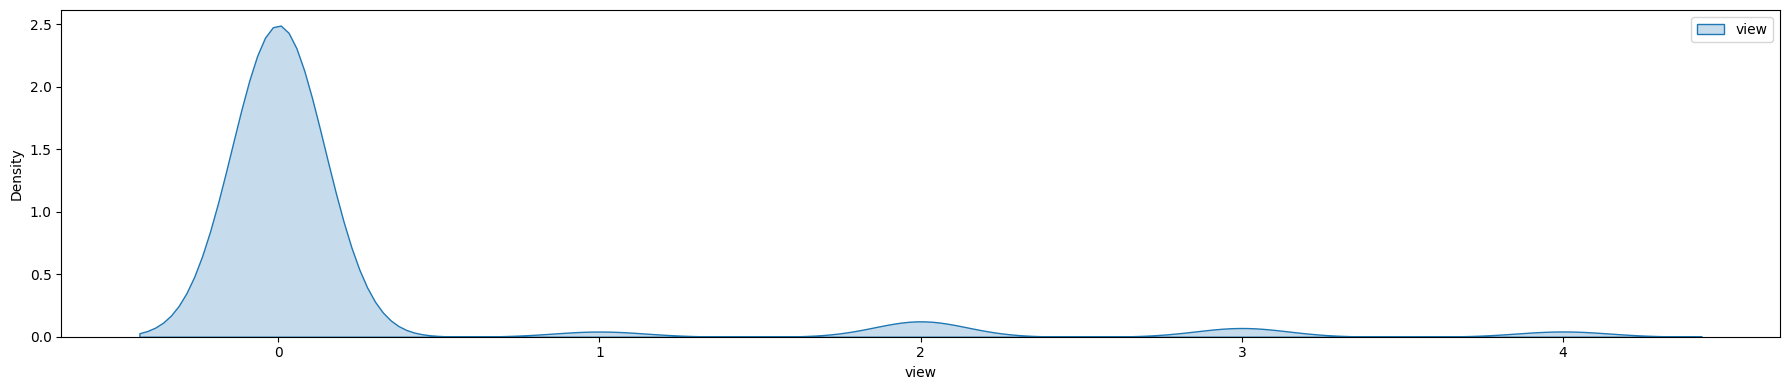

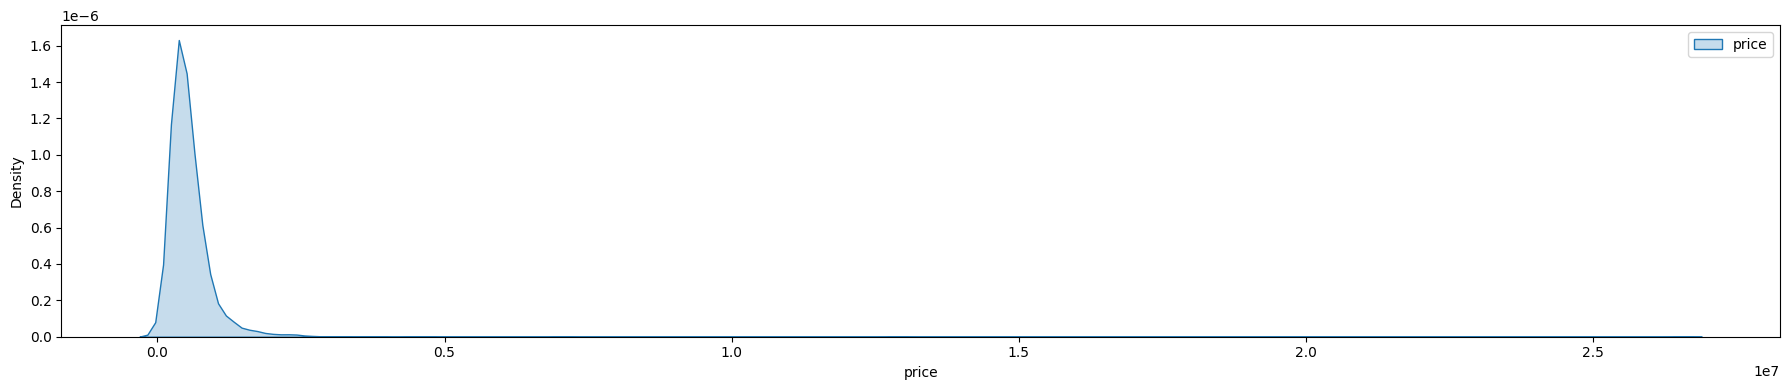

In [29]:

data = df2.copy()
# data.drop(columns=['year', 'month', 'day'], inplace=True)

data.drop(columns=['city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5'], inplace=True)

for i in data.columns:
    plt.figure(figsize=(18, 4))
    sns.kdeplot(data[i], label=i, fill=True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# since the data here is not normally distributed you cant apply 'Z score'

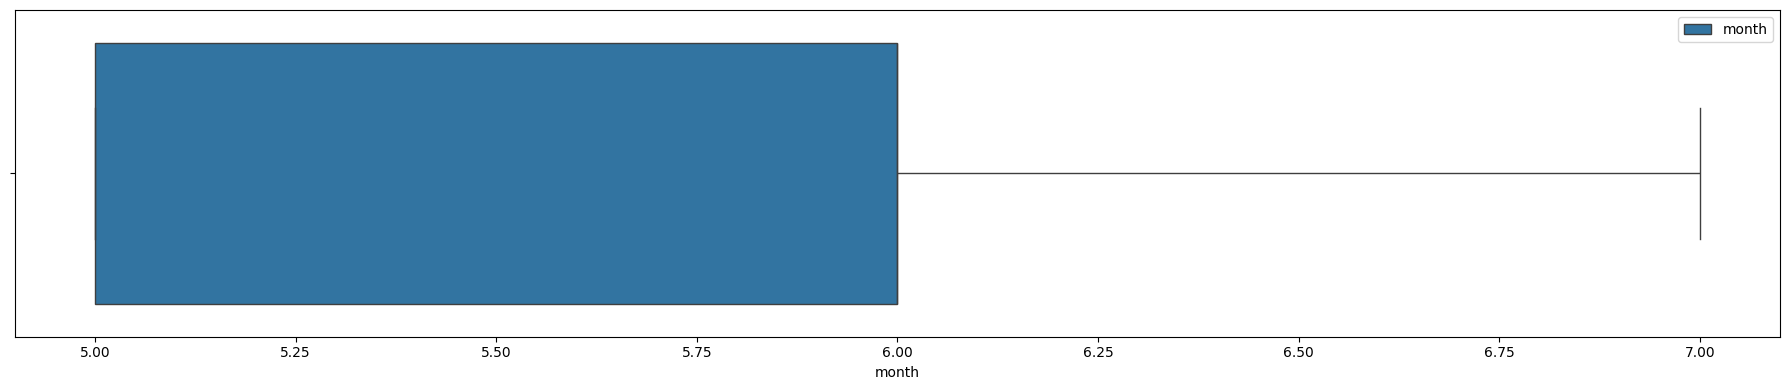

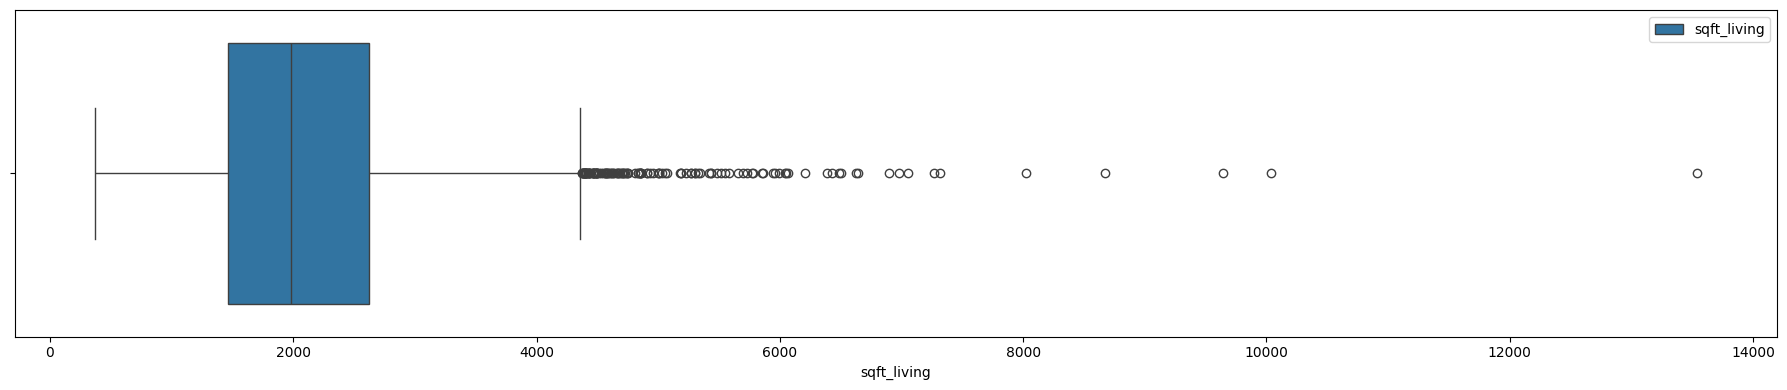

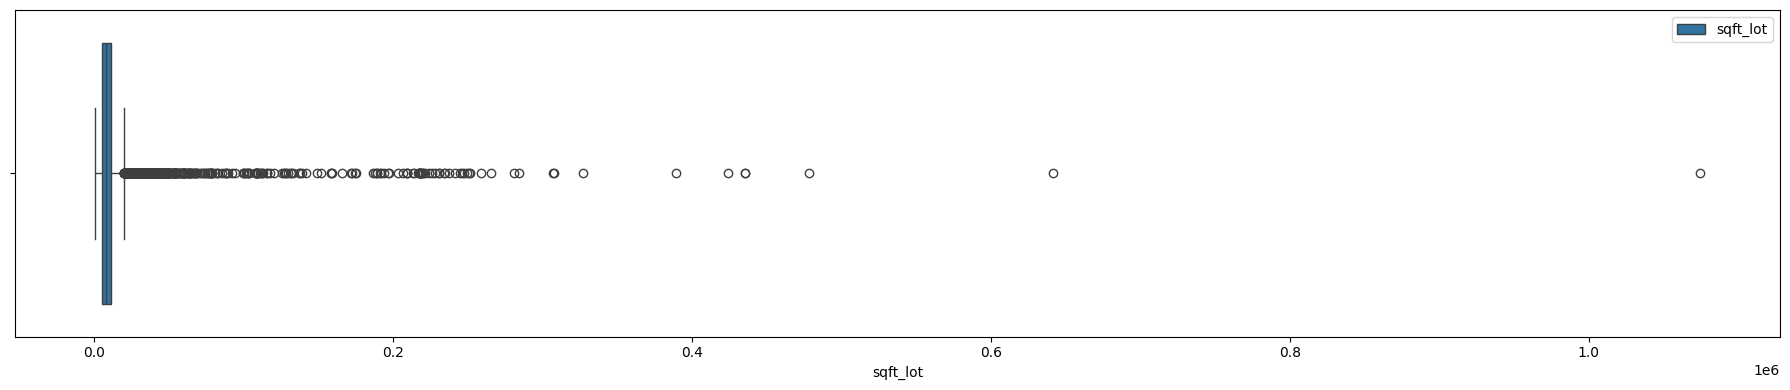

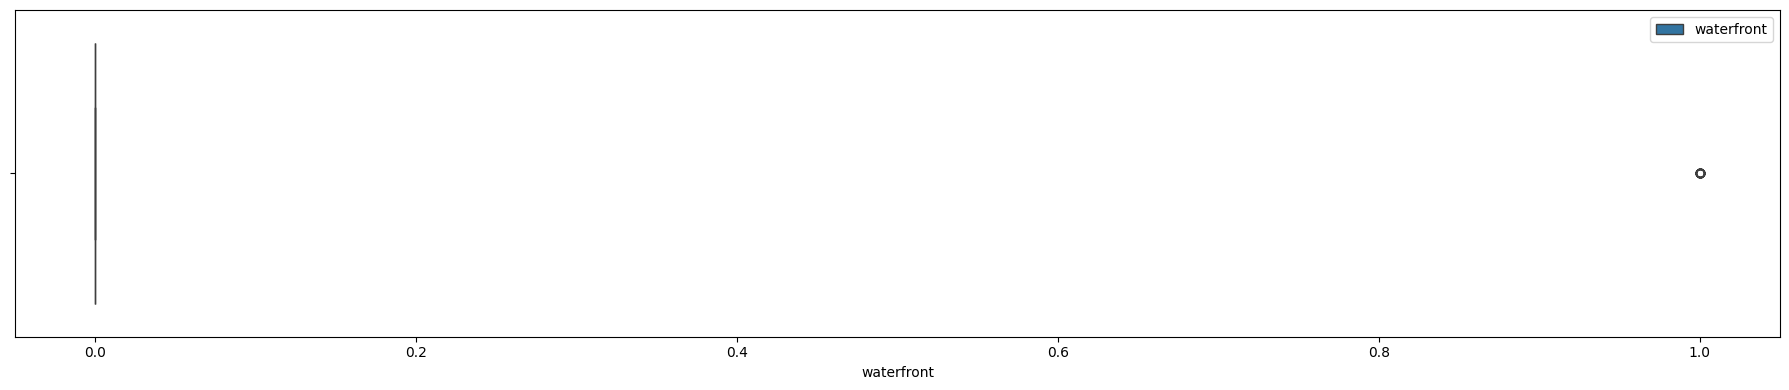

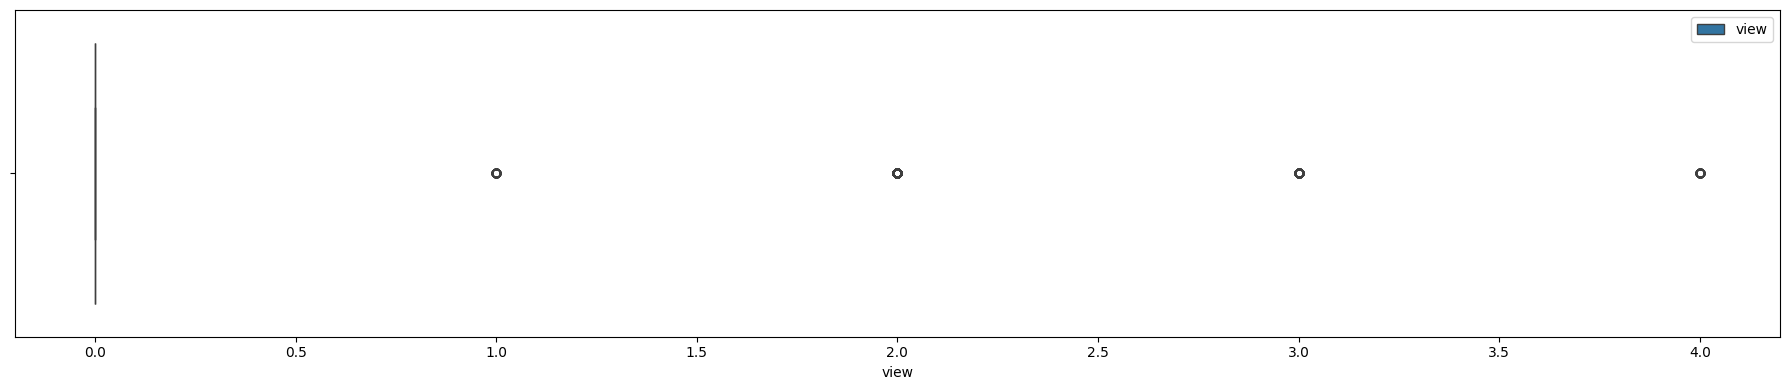

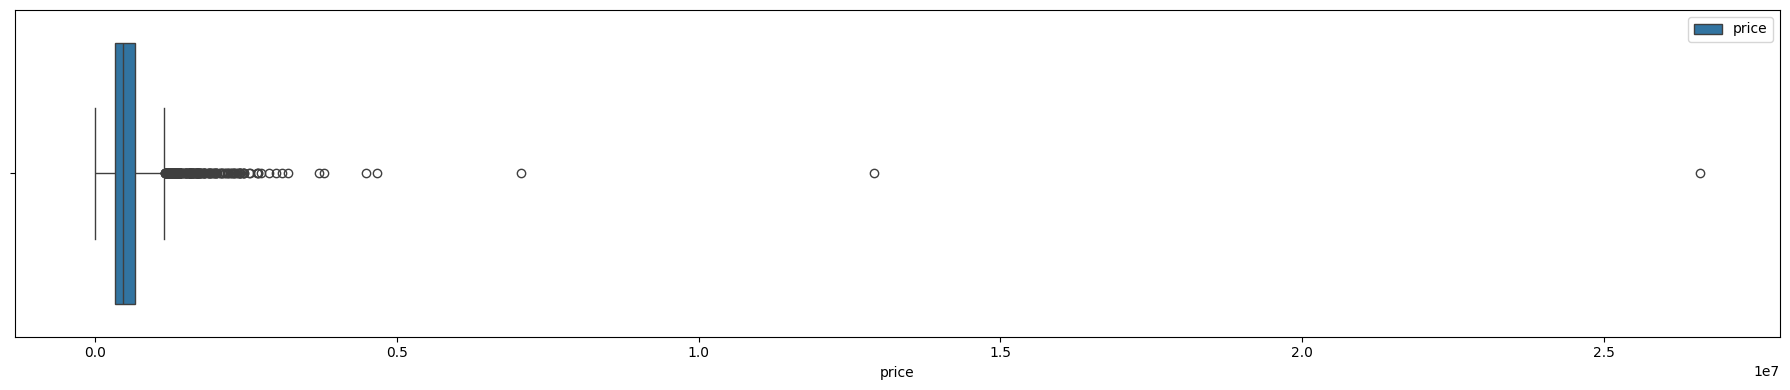

In [30]:
for i in data.columns:
    plt.figure(figsize=(18, 4))
    sns.boxplot(x=df2[i], label=i)
    plt.legend()
    plt.tight_layout()
    plt.show()


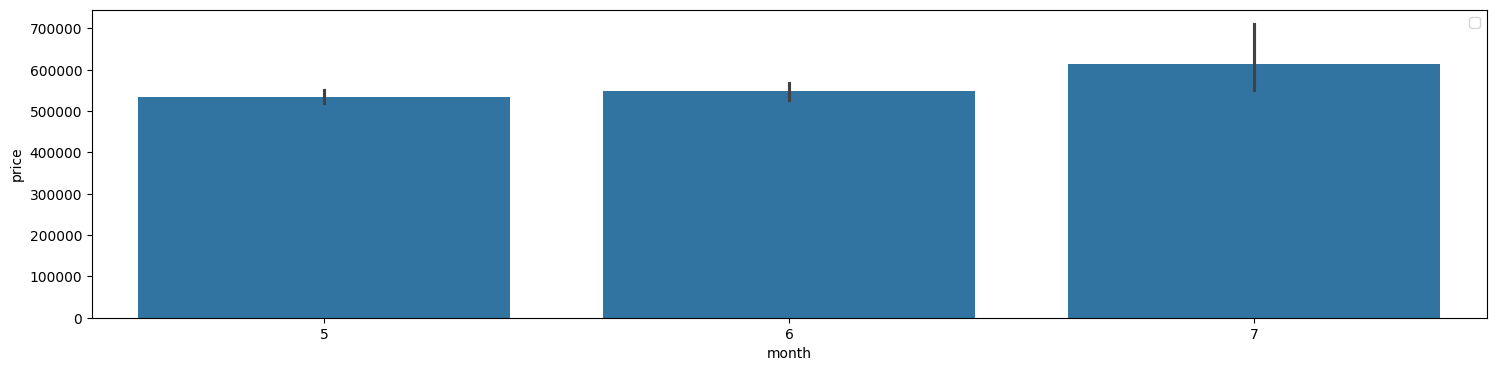

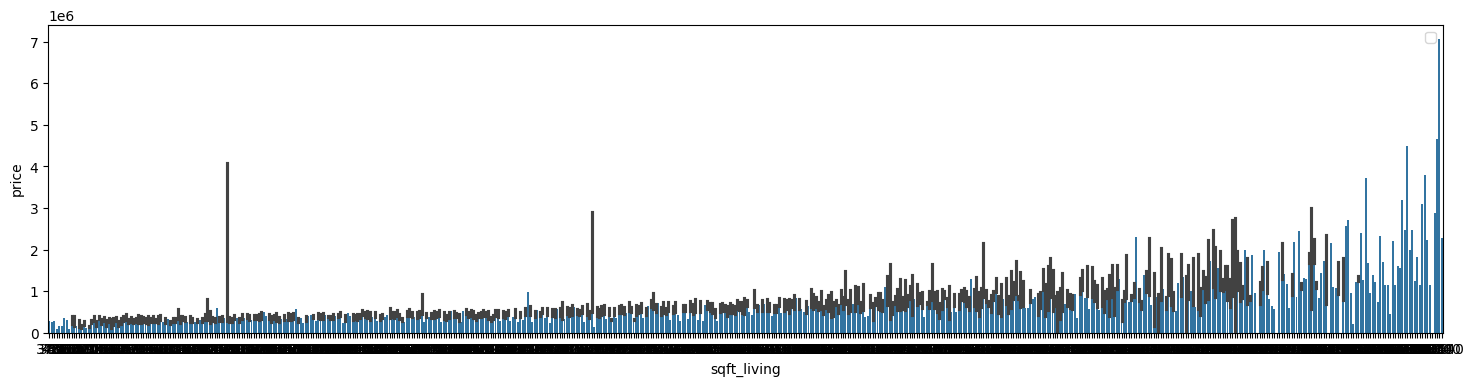

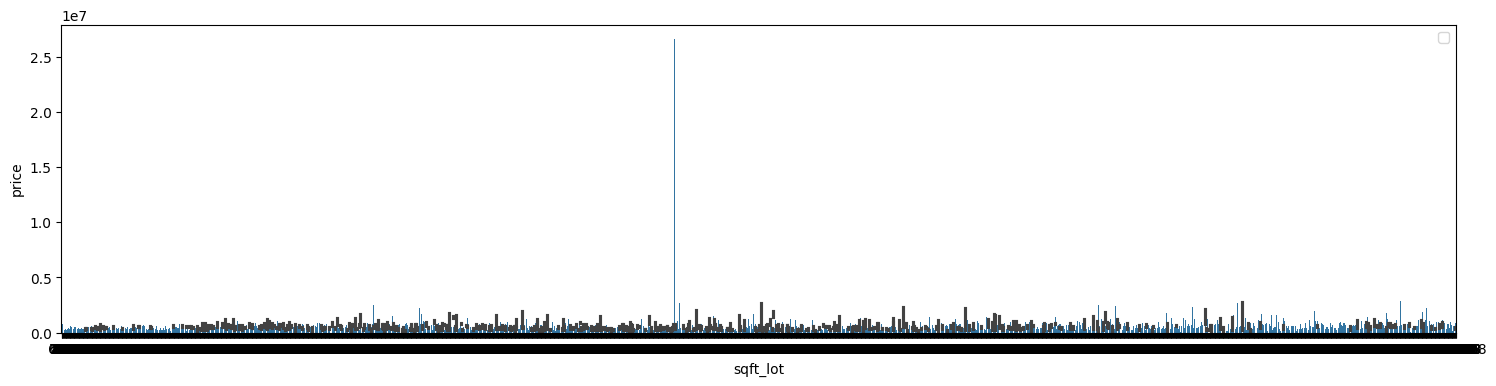

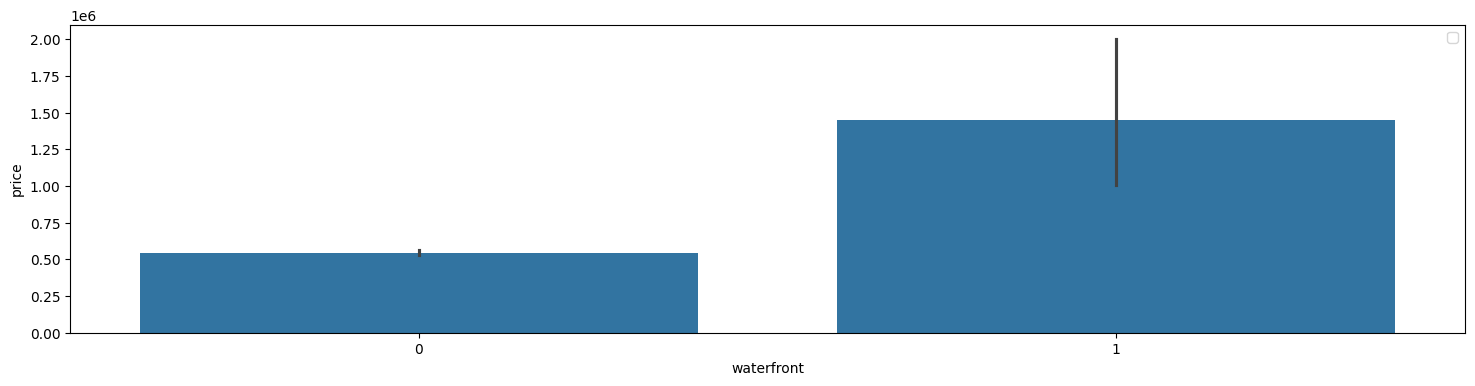

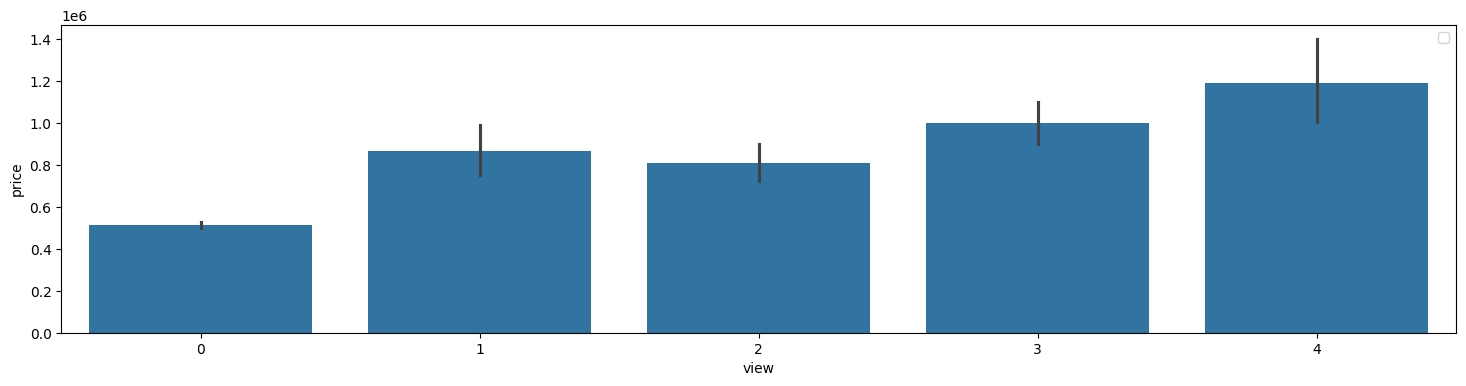

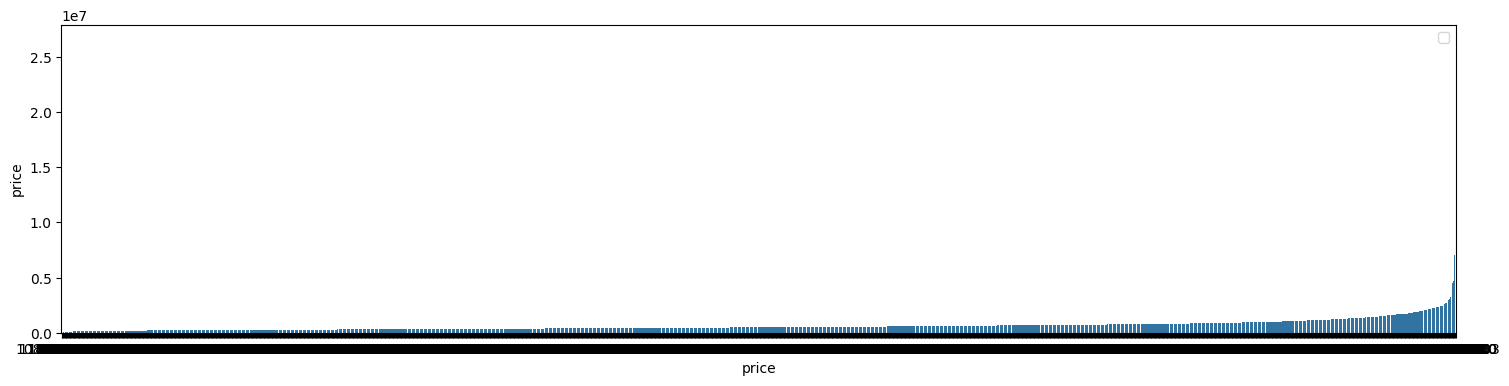

In [31]:
# plt.figure(figsize=(18,4))
# # sns.kdeplot(df2['price'], fill=True, label='price')
# sns.scatterplot(x=df['sqft_living'], y=df['price'])
# plt.legend()
# plt.show()


for i in data.columns:
    plt.figure(figsize=(18,4))
    sns.barplot(x=df[i], y=df['price'])
    plt.legend()
    plt.show()


